In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

FEATURE_DATASET_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData\final_features.csv"
MODELS_DIR = r"C:\Users\Enjoy\OneDrive\Desktop\STData\models"

os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style("whitegrid")

print("Configuration complete.")
print(f"Feature dataset will be loaded from: {FEATURE_DATASET_PATH}")
print(f"Trained models will be saved to: {MODELS_DIR}")

Configuration complete.
Feature dataset will be loaded from: C:\Users\Enjoy\OneDrive\Desktop\STData\final_features.csv
Trained models will be saved to: C:\Users\Enjoy\OneDrive\Desktop\STData\models


In [2]:
print("--- Loading the feature dataset ---")
df = pd.read_csv(FEATURE_DATASET_PATH)
print("Dataset loaded successfully.")

--- Loading the feature dataset ---
Dataset loaded successfully.


In [3]:
print("--- Dataset Info: Checking structure, columns, and data types ---")
df.info()

--- Dataset Info: Checking structure, columns, and data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trial_id                    235 non-null    object 
 1   response_time               235 non-null    float64
 2   eeg_delta_mean              235 non-null    float64
 3   eeg_delta_std               235 non-null    float64
 4   eeg_delta_var               235 non-null    float64
 5   eeg_delta_min               235 non-null    float64
 6   eeg_delta_max               235 non-null    float64
 7   eeg_delta_spectral_entropy  235 non-null    float64
 8   eeg_theta_mean              235 non-null    float64
 9   eeg_theta_std               235 non-null    float64
 10  eeg_theta_var               235 non-null    float64
 11  eeg_theta_min               235 non-null    float64
 12  eeg_theta_max             

In [4]:
print("--- Displaying the first 20 rows of the dataset ---")
display(df.head(20))

--- Displaying the first 20 rows of the dataset ---


,trial_id,response_time,eeg_delta_mean,eeg_delta_std,eeg_delta_var,eeg_delta_min,eeg_delta_max,eeg_delta_spectral_entropy,eeg_theta_mean,eeg_theta_std,...,eye_pupil_mean,eye_pupil_std,eye_pupil_var,eye_pupil_min,eye_pupil_max,eye_gaze_variability,eye_avg_fixation_duration,eye_fixation_count,eye_avg_saccade_amplitude,eye_blink_count
0,student_1_trial_0,10.369816,0.239537,0.146903,0.021580,-0.020135,0.567931,1.172398,0.176614,0.071372,...,0.190284,1.777635,3.159986,-1.0,3.382889,439.711293,1358.819046,1097,7.773025,882
1,student_1_trial_10,9.659429,0.878957,0.181840,0.033066,0.104589,1.174160,0.309628,0.717378,0.205096,...,0.112260,1.705860,2.909959,-1.0,3.629654,498.161723,345.905025,980,7.329646,847
2,student_1_trial_11,21.042414,0.931256,0.184803,0.034152,0.577722,1.333250,0.255953,0.616433,0.178468,...,0.108177,1.715587,2.943238,-1.0,3.520447,543.885934,322.570735,2005,8.103427,1803
3,student_1_trial_12,6.252160,0.350807,0.096269,0.009268,0.164777,0.475770,0.385995,0.130774,0.068989,...,0.036304,1.640583,2.691511,-1.0,3.485512,537.724470,253.741274,590,6.617334,558
4,student_1_trial_13,7.533956,0.856298,0.199314,0.039726,0.452667,1.067846,0.319499,0.405921,0.243591,...,0.204319,1.807572,3.267316,-1.0,3.480156,549.312576,260.036277,722,7.980705,648
5,student_1_trial_14,4.509170,0.935241,0.147875,0.021867,0.531340,1.155292,0.186855,0.665842,0.072800,...,0.280102,1.892563,3.581794,-1.0,3.436699,537.774516,318.087099,427,7.948189,381
6,student_1_trial_15,3.050043,1.122747,0.063572,0.004041,0.987714,1.209658,0.026373,0.848657,0.038773,...,0.302554,1.892654,3.582139,-1.0,3.433167,506.834124,334.411205,280,9.484643,255
7,student_1_trial_16,5.445206,1.071609,0.074585,0.005563,0.877774,1.212346,0.040881,0.754181,0.089095,...,0.235018,1.852099,3.430273,-1.0,3.522408,562.038904,258.947988,494,8.788331,449
8,student_1_trial_17,11.453221,1.254049,0.136330,0.018586,0.999408,1.527173,0.085854,0.755336,0.083602,...,0.284269,1.910492,3.649981,-1.0,3.661026,540.479072,312.436620,1086,7.627430,949
9,student_1_trial_19,12.241088,0.971198,0.200361,0.040145,0.312216,1.251332,0.274053,0.664761,0.187678,...,0.229386,1.827142,3.338449,-1.0,3.435638,580.726352,301.518203,1152,8.417200,1025


--- Analyzing the distribution of the target variable: 'response_time' ---


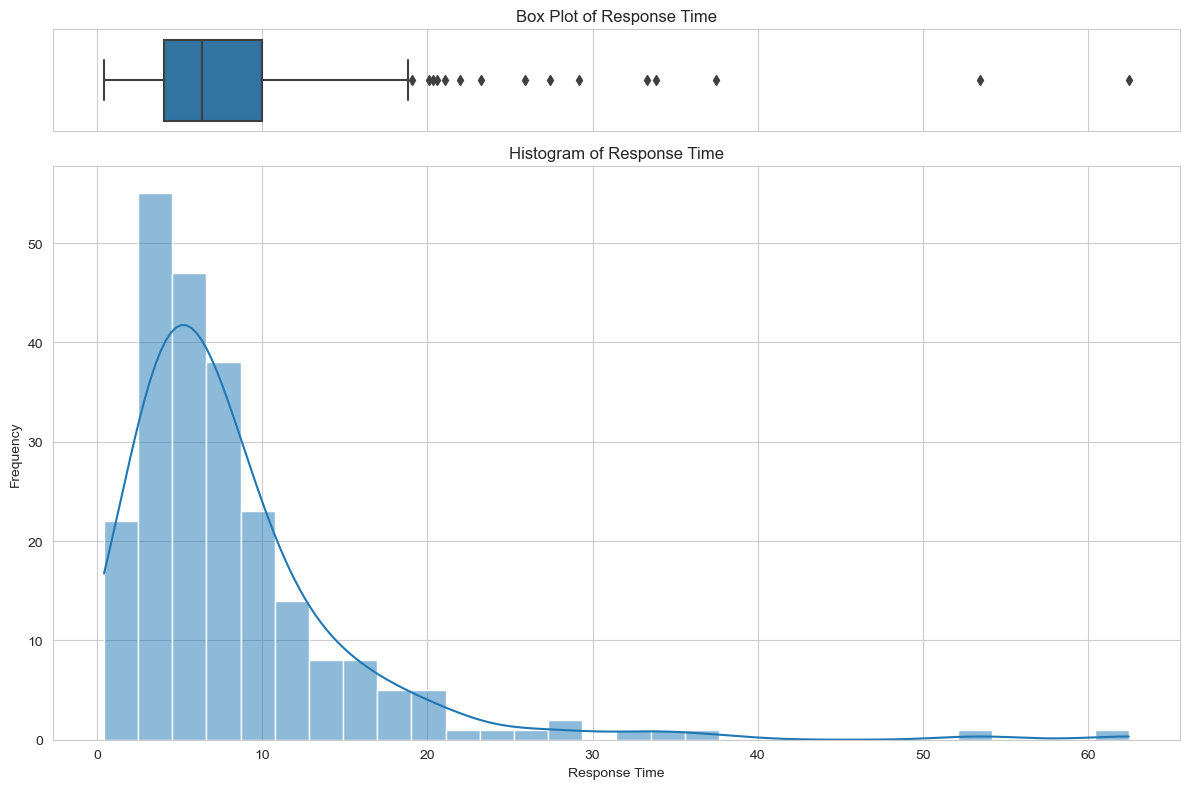


--- Descriptive Statistics for 'response_time' ---


count    235.000000
mean       8.321712
std        7.549507
min        0.435931
25%        4.095509
50%        6.372439
75%        9.997472
max       62.452913
Name: response_time, dtype: float64

In [5]:
print("--- Analyzing the distribution of the target variable: 'response_time' ---")

fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# Box plot
sns.boxplot(x=df['response_time'], ax=ax_box)
ax_box.set_title('Box Plot of Response Time')
ax_box.set_xlabel('')

# Histogram
sns.histplot(df['response_time'], ax=ax_hist, kde=True, bins=30)
ax_hist.set_title('Histogram of Response Time')
ax_hist.set_xlabel('Response Time')
ax_hist.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n--- Descriptive Statistics for 'response_time' ---")
display(df['response_time'].describe())

In [6]:
print("--- Separating features (X) and target (y) ---")

X = df.drop(columns=['trial_id', 'response_time'])
y = df['response_time']

print(f"Shape of features matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")

--- Separating features (X) and target (y) ---
Shape of features matrix X: (235, 41)
Shape of target vector y: (235,)


In [7]:
print("--- Splitting data into training (80%) and testing (20%) sets ---")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shapes: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shapes:  X_test={X_test.shape}, y_test={y_test.shape}")

--- Splitting data into training (80%) and testing (20%) sets ---
Training set shapes: X_train=(188, 41), y_train=(188,)
Testing set shapes:  X_test=(47, 41), y_test=(47,)


In [8]:
print("--- Scaling features using StandardScaler ---")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Features have been successfully scaled.")

--- Scaling features using StandardScaler ---
Features have been successfully scaled.


In [9]:
print("--- Displaying the first 20 rows of the SCALED training data ---")

df_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
display(df_train_scaled.head(20))

--- Displaying the first 20 rows of the SCALED training data ---


,eeg_delta_mean,eeg_delta_std,eeg_delta_var,eeg_delta_min,eeg_delta_max,eeg_delta_spectral_entropy,eeg_theta_mean,eeg_theta_std,eeg_theta_var,eeg_theta_min,...,eye_pupil_mean,eye_pupil_std,eye_pupil_var,eye_pupil_min,eye_pupil_max,eye_gaze_variability,eye_avg_fixation_duration,eye_fixation_count,eye_avg_saccade_amplitude,eye_blink_count
0,-0.630376,-0.378785,-0.469911,-0.345339,-0.821235,-0.171036,-0.294755,-0.544639,-0.579577,-0.033248,...,-0.133778,-0.266510,-0.408422,0.0,-0.882408,0.304084,-0.280014,0.139565,1.096083,-0.174914
1,-0.053573,-0.673391,-0.649936,0.281606,-0.131038,-0.618870,0.194546,-0.119481,-0.289101,0.242282,...,0.772942,0.773210,0.820027,0.0,0.732697,0.598053,-0.325102,-0.599230,0.443286,-0.460851
2,0.529138,-0.950079,-0.788981,0.654097,0.059819,-0.762652,0.386880,-1.247733,-0.905421,0.751260,...,-1.009508,-0.903176,-1.034914,0.0,-1.136376,0.909826,-0.646396,-1.038572,0.182992,-0.607904
3,2.910484,-0.803104,-0.718743,2.704117,2.775678,-0.837237,2.763808,-1.039793,-0.829109,2.738860,...,-0.052305,-0.047836,-0.171206,0.0,-0.505734,0.076513,-0.195870,-0.358794,0.742740,-0.388492
4,0.734491,-0.799042,-0.716685,0.887826,0.412499,-0.753583,0.496845,-0.789225,-0.714774,0.722505,...,1.322733,1.344689,1.603719,0.0,1.316824,-0.242715,-0.255416,-0.199232,0.471530,-0.351145
5,0.032137,-0.524665,-0.563176,0.177194,-0.093189,-0.584983,0.561165,-0.949921,-0.790913,0.758856,...,0.141248,0.158175,0.062579,0.0,-0.132515,-0.264571,-0.533004,-0.188303,-0.292179,-0.310297
6,0.398275,-0.138437,-0.298614,0.556937,0.244046,-0.583264,0.082554,-0.227113,-0.369294,0.273428,...,0.546559,0.409209,0.360975,0.0,0.059414,-1.219050,0.333511,0.006232,-0.149649,-0.317299
7,0.706592,-0.810843,-0.722646,0.935182,0.468026,-0.768939,0.086034,-0.594347,-0.608940,0.384921,...,0.715494,0.796357,0.850275,0.0,0.907222,-0.400725,-0.432730,-0.983928,-0.989006,-0.696603
8,-0.826814,0.681905,0.451360,-1.320888,-0.448550,1.094491,-0.566599,0.704847,0.474730,-0.871807,...,0.885997,0.794635,0.848020,0.0,0.468148,-1.867668,1.856771,1.357045,-1.062642,0.279083
9,-1.142150,-0.803233,-0.718808,-0.725991,-1.640118,0.254814,-0.883331,-0.616444,-0.621684,-0.485842,...,-0.325607,0.050150,-0.061257,0.0,0.309580,0.517596,-0.293955,-0.854967,0.190642,-0.621909


In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, eval_metric='mae')
}

results = {}
best_model = None
best_mae = float('inf')

print("--- Starting Model Training and Evaluation ---")
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate model performance
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE": mae,
        "RMSE": np.sqrt(mse),
        "R2 Score": r2
    }
    
    print(f"  -> MAE: {mae:.4f}, RMSE: {np.sqrt(mse):.4f}, R2 Score: {r2:.4f}")

    # Check if this is the best model so far and save it
    if mae < best_mae:
        best_mae = mae
        best_model = model
        print(f"  -> New best model found: {name}. It will be saved.")

print("\n--- Model training complete ---")

--- Starting Model Training and Evaluation ---

--- Training Linear Regression ---
  -> MAE: 0.3271, RMSE: 0.4455, R2 Score: 0.9942
  -> New best model found: Linear Regression. It will be saved.

--- Training Random Forest ---
  -> MAE: 0.8064, RMSE: 2.1964, R2 Score: 0.8600

--- Training XGBoost ---
  -> MAE: 1.0675, RMSE: 3.9759, R2 Score: 0.5412

--- Model training complete ---


In [11]:
joblib.dump(best_model, os.path.join(MODELS_DIR, "gb_model.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))

print(f"Best model ({best_model.__class__.__name__}) and the scaler have been saved to the '{MODELS_DIR}' directory.")

Best model (LinearRegression) and the scaler have been saved to the 'C:\Users\Enjoy\OneDrive\Desktop\STData\models' directory.


In [12]:
results_df = pd.DataFrame(results).T.sort_values(by="MAE", ascending=True)

print("--- Final Model Comparison ---")
display(results_df)

--- Final Model Comparison ---


,MAE,RMSE,R2 Score
Linear Regression,0.327075,0.445536,0.994238
Random Forest,0.806414,2.196364,0.859976
XGBoost,1.067492,3.975882,0.541162


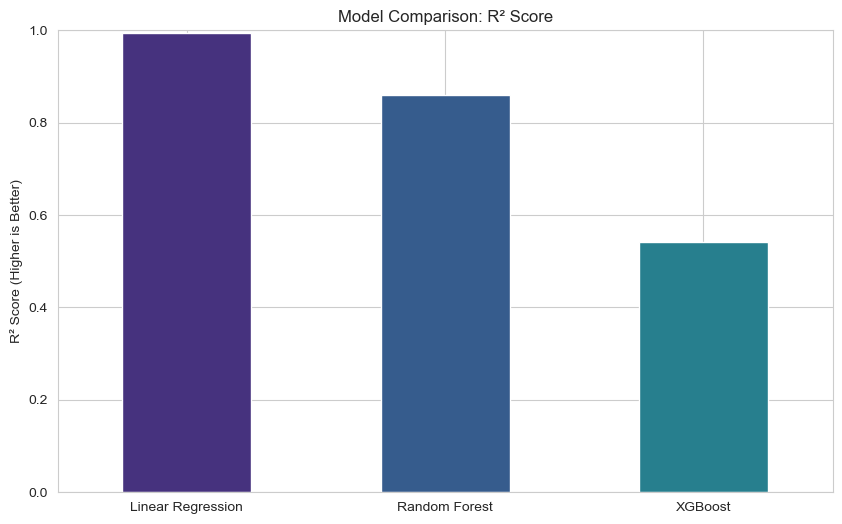

In [13]:
plt.figure(figsize=(10, 6))
results_df['R2 Score'].sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis"))
plt.title('Model Comparison: R² Score')
plt.ylabel('R² Score (Higher is Better)')
plt.xticks(rotation=0)
plt.ylim(0, 1) 
plt.show()